# Exploratory Data Analysis, Visualization and Business Insights

This notebook performs deeper exploratory analysis on the cleaned laptop review dataset. 
It covers univariate, bivariate, and correlation analysis, and translates the findings into business insights and recommendations.

## Step 1: Load the cleaned dataset

We load the cleaned dataset produced in the previous notebook, since this analysis should build on already cleaned data rather than the raw file.

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# load the cleaned dataset from the previous stage
df = pd.read_csv("../data/processed/processed_data.csv")
print("Shape:", df.shape)
df.head(3)

Shape: (16991, 7)


,product_name,overall_rating,no_ratings,no_reviews,rating,title,review
0,Apple MacBook AIR Apple M2 - (8 GB/256 GB SSD/...,4.7,15210,900,5,Perfect product!,"Loved it, it's my first MacBook that I earned ..."
1,Apple MacBook AIR Apple M2 - (8 GB/256 GB SSD/...,4.7,15210,900,5,Fabulous!,Battery lasted longer than my first relationsh...
2,Apple MacBook AIR Apple M2 - (8 GB/256 GB SSD/...,4.7,15210,900,5,Fabulous!,Such a great deal.. very happy with the perfor...


## Step 1b: Dataset overview

A quick structural overview of the dataset before deeper analysis, showing column types 
and summary statistics for all numeric columns.

In [26]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 16991 entries, 0 to 16990
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   product_name    16991 non-null  str    
 1   overall_rating  16991 non-null  float64
 2   no_ratings      16991 non-null  int64  
 3   no_reviews      16991 non-null  int64  
 4   rating          16991 non-null  int64  
 5   title           16991 non-null  str    
 6   review          16991 non-null  str    
dtypes: float64(1), int64(3), str(3)
memory usage: 929.3 KB


In [27]:
df.describe()

,overall_rating,no_ratings,no_reviews,rating
count,16991.000000,16991.000000,16991.000000,16991.000000
mean,4.185622,2510.552881,218.139074,4.214937
std,0.217054,2924.338449,257.185361,1.185478
min,3.300000,1.000000,1.000000,1.000000
25%,4.100000,628.000000,60.000000,4.000000
50%,4.200000,1493.000000,133.000000,5.000000
75%,4.300000,2985.000000,292.000000,5.000000
max,5.000000,15729.000000,2171.000000,5.000000


## Step 2: Extract brand from product_name

The product_name column starts with the brand, followed by processor and configuration details. 
Extracting just the brand gives us a clean categorical variable to group and compare by,similar to a category or region column in a typical business dataset.

In [28]:
# look at a sample of product names to understand the pattern before extracting
df["product_name"].sample(15, random_state=1).tolist()

['HP 15s Intel Core i5 11th Gen 1155G7 - (16 GB/512 GB SSD/Windo...',
 'ASUS Chromebook Intel Celeron Dual Core N4500 - (4 GB/128 GB E...',
 'Lenovo LOQ Intel Core i5 12th Gen 12450HX - (12 GB/512 GB SSD/...',
 'ASUS Vivobook 14 Intel Core i3 13th Gen 1315U - (8 GB/512 GB S...',
 'HP 15s Intel Core i3 12th Gen 1215U - (8 GB/512 GB SSD/Windows...',
 'HP 15s Intel Core i3 12th Gen 1215U - (8 GB/512 GB SSD/Windows...',
 'SAMSUNG Galaxy Book4 Intel Core i5 13th Gen 1335U - (8 GB/512 ...',
 'HP (15s-fq5007TU) Intel Core i3 12th Gen 1215U - (8 GB/512 GB ...',
 'HP Intel Core i3 11th Gen 1115G4 - (8 GB/512 GB SSD/Windows 10...',
 'Infinix Y4 Max Series Intel Core i3 13th Gen 1315U - (16 GB/51...',
 'HP Chromebook MediaTek MT8183 - (4 GB/32 GB EMMC Storage/Chrom...',
 'HP Pavilion AMD Ryzen 5 Dual Core 5500U - (8 GB/512 GB SSD/Win...',
 'ASUS TUF Gaming F15 - AI Powered Gaming Intel Core i5 11th Gen...',
 'Acer Aspire Lite AMD Ryzen 3 Quad Core 5300U - (8 GB/512 GB SS...',
 'MSI Thin 15 Intel 

In [29]:
# split each product name on the first space, keep only the first part as the brand
df["brand"] = df["product_name"].str.split(" ").str[0]

df["brand"].value_counts()

brand
HP           4387
ASUS         3046
Acer         2810
Lenovo       2387
MSI          1451
DELL          742
Infinix       608
SAMSUNG       335
CHUWI         282
Apple         232
Primebook     200
Ultimus       116
walker        100
realme        100
ZEBRONICS      99
Colorful       54
AXL            33
GIGABYTE        4
Avita           3
Thomson         2
Name: count, dtype: int64

The brand extraction worked cleanly across all rows, producing 20 distinct real brand names with no invalid or broken values. HP, ASUS, Acer, and Lenovo are the most represented brands in the dataset, while several brands such as GIGABYTE, Avita, and Thomson have very few reviews, which will be kept in mind when comparing brands later, since small sample sizes can be misleading.

## Step 3: Univariate analysis - rating distribution

We start by looking at individual variables on their own, before comparing them to each other. 
The rating column, the star rating given by each reviewer, is the most central variable in this dataset.

In [30]:
# count how many reviews fall into each star rating
df["rating"].value_counts().sort_index()

rating
1    1295
2     453
3    1376
4    4048
5    9819
Name: count, dtype: int64

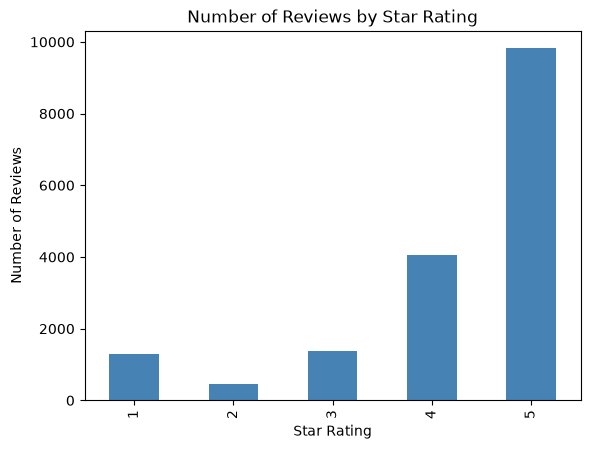

In [31]:
# bar chart showing how many reviews exist at each star rating
df["rating"].value_counts().sort_index().plot(kind="bar", color="steelblue")
plt.title("Number of Reviews by Star Rating")
plt.xlabel("Star Rating")
plt.ylabel("Number of Reviews")
plt.show()

## Step 4: Univariate analysis - review length

We did not carry the review_length column over from the previous notebook, since each notebook 
loads the data fresh. We recreate it here, then look at its distribution using a histogram.

In [32]:
# create a column measuring how many characters are in each review
df["review_length"] = df["review"].str.len()

df["review_length"].describe()

count    16991.000000
mean        97.503384
std        124.067123
min          2.000000
25%         17.000000
50%         46.000000
75%        122.000000
max        533.000000
Name: review_length, dtype: float64

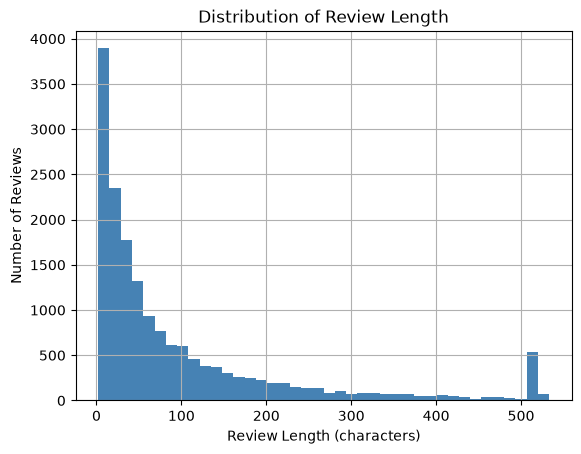

In [33]:
# histogram showing how review lengths are distributed
df["review_length"].hist(bins=40, color="steelblue")
plt.title("Distribution of Review Length")
plt.xlabel("Review Length (characters)")
plt.ylabel("Number of Reviews")
plt.show()

In [34]:
# look at reviews right at the top of the range
df[df["review_length"] >= 500]["review"].head(5).tolist()

["When i ordered and came to know about seller review,i was scared that in what condition i will get macbook. but i was wrong.\r\n\r\nThis is my first macbook and i am fully satisfied with the product with original packaging of apple and got genuine product.\r\n\r\nIt's very thin and light and looks very premium.\r\n\r\nAs A software developer, i installed intellij idea ide and guess what.\r\nIt's magic,it is opening just in a click and within 5 seconds.\r\nGreat performance, no heating issue, sound quality awesome an...\r\nREAD MORE",
 'My first MacBook and also my first laptop. First I thought of buying a windows laptop as macbooks are way more expensive. But during the sale I bought it at 73k which is a steal deal. I am a college student and mainly bought it for coding, streaming videos and movies and also for some editing tasks.\r\n\r\nI would like to tell you if you are not a gamer this is one of the best laptops you can have in this price range. Loved the design, the colour, the 

## Note on the spike in review length distribution

The histogram shows an unusual spike around 500 to 530 characters, separate from the natural 
declining tail. Investigation of the actual review text in this range showed that these reviews 
consistently end mid-sentence, followed by the literal text READ MORE. This indicates that Flipkart 
truncates long reviews on the page behind a Read More link, and the web scraper captured only the 
visible truncated text for these reviews, not the full original review. 

This is a limitation of the dataset rather than a genuine pattern in review length. It means a 
meaningful number of the longest reviews in this dataset are incomplete, which is important to 
keep in mind for the aspect extraction stage later, since cutting off mid-sentence could affect 
how well aspects and sentiment are detected in these specific reviews.

In [35]:
# count how many reviews were likely truncated by the scraper
truncated_count = df["review"].str.contains("READ MORE", case=False, na=False).sum()
print(f"{truncated_count} reviews ({truncated_count/len(df)*100:.1f}%) contain a READ MORE marker")

621 reviews (3.7%) contain a READ MORE marker


A total of 621 reviews, about 3.7 percent of the dataset, contain the READ MORE marker and are 
therefore likely truncated. This is a small enough portion that it should not significantly affect 
overall analysis, but it will be kept in mind for the aspect and sentiment extraction stage.

## Step 5: Bivariate analysis - rating vs review length

We already saw in the earlier data understanding notebook that average review length differs 
slightly across star ratings. Here we look at this more closely using a boxplot, which shows 
not just the average but the full spread of values for each rating.

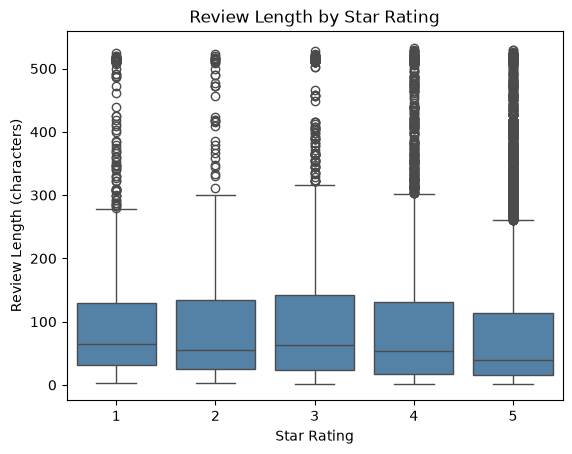

In [36]:
# boxplot showing review length spread for each star rating
sns.boxplot(data=df, x="rating", y="review_length", color="steelblue")
plt.title("Review Length by Star Rating")
plt.xlabel("Star Rating")
plt.ylabel("Review Length (characters)")
plt.show()

The boxplot shows that review length is broadly similar across ratings 1 to 4, with medians 
in a similar range and overlapping spread. Rating 5 stands out as noticeably shorter on average, 
consistent with the earlier finding that highly satisfied customers tend to write brief reviews. 
There is no strong evidence that lower ratings consistently produce longer reviews, the relationship 
is weaker than initially expected, and mainly driven by 5 star reviews being distinctly shorter 
rather than negative reviews being distinctly longer.

## Step 6: Bivariate analysis - brand vs rating

Here we compare average rating across brands to see which brands tend to be rated higher or lower. 
Since some brands have very few reviews, as seen in the brand counts earlier, we need to be careful 
not to draw strong conclusions from brands with very small sample sizes.

In [37]:
# average rating per brand, sorted from highest to lowest
brand_rating = df.groupby("brand")["rating"].agg(["mean", "count"]).sort_values("mean", ascending=False)
brand_rating

,mean,count
brand,,
Primebook,4.865000,200
Apple,4.823276,232
realme,4.790000,100
Avita,4.666667,3
SAMSUNG,4.632836,335
Thomson,4.500000,2
GIGABYTE,4.500000,4
Colorful,4.444444,54
Infinix,4.319079,608


## Filtering brands with very few reviews before comparison

Some brands, such as Avita, Thomson, and GIGABYTE, have very few reviews, in some cases only 2 or 3. 
Averages based on such small counts are unreliable and can be misleading if shown alongside brands 
with thousands of reviews. Before visualizing brand comparisons, we filter to only include brands 
with at least 30 reviews, giving a fairer and more trustworthy comparison.

In [38]:
# keep only brands with at least 30 reviews, for a more reliable comparison
brand_rating_filtered = brand_rating[brand_rating["count"] >= 30].sort_values("mean", ascending=False)
brand_rating_filtered

,mean,count
brand,,
Primebook,4.865000,200
Apple,4.823276,232
realme,4.790000,100
SAMSUNG,4.632836,335
Colorful,4.444444,54
Infinix,4.319079,608
MSI,4.276361,1451
ASUS,4.276100,3046
HP,4.233645,4387


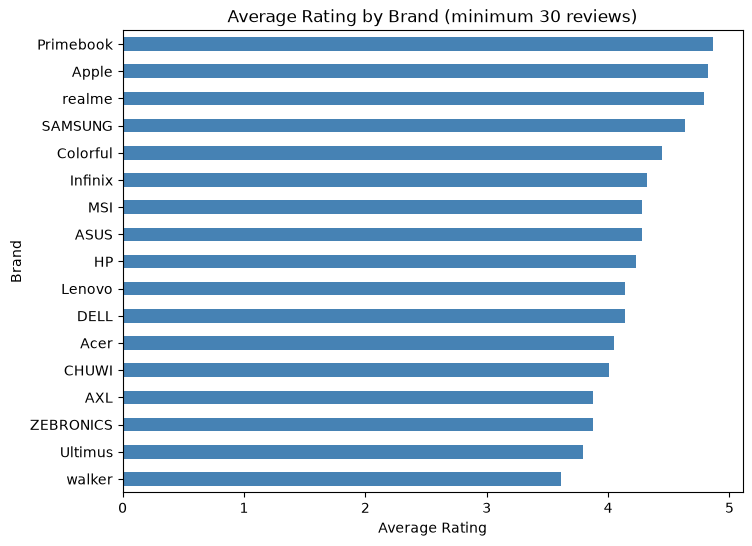

In [39]:
# horizontal bar chart, ordered from highest to lowest average rating
plt.figure(figsize=(8, 6))
brand_rating_filtered["mean"].sort_values().plot(kind="barh", color="steelblue")
plt.title("Average Rating by Brand (minimum 30 reviews)")
plt.xlabel("Average Rating")
plt.ylabel("Brand")
plt.show()

## Insight: Brand vs Rating

What happened: Primebook, Apple, and realme have the highest average ratings among brands with 
at least 30 reviews, all above 4.7. Walker, Ultimus, and ZEBRONICS have the lowest, around 3.6 to 3.9.

Why it matters: The four most reviewed brands in the dataset, HP, ASUS, Acer, and Lenovo, all sit 
in the middle of the pack, between 4.05 and 4.28. This means the brands with the largest presence 
in this market are performing decently but not exceptionally, while smaller or newer brands like 
Primebook and realme are earning stronger customer satisfaction, though from a smaller review base.

Recommendation: Sellers focused on brands like walker or Ultimus should investigate the recurring 
complaints in their reviews to understand what is driving lower ratings, this is explored further 
in the aspect extraction stage. Larger brands such as HP and Lenovo have room to close the gap with 
top performers like Apple and Primebook, and could benefit from identifying which specific product 
aspects are holding their ratings back.

## Step 7: Bivariate analysis - does popularity relate to rating

Here we check whether products with more ratings, meaning more popular products, tend to have 
higher or lower overall ratings. We use overall_rating and no_ratings, which are product level 
fields, so we first reduce the dataset to one row per product to avoid counting the same product 
multiple times.

In [40]:
# reduce to one row per product using the product-level columns
product_level = df.drop_duplicates(subset="product_name")[["product_name", "overall_rating", "no_ratings"]]
product_level.shape

(365, 3)

## Scatter plot: number of ratings vs overall rating

A scatter plot lets us see if there is any visible relationship between how popular a product is 
and how well it is rated, without assuming the relationship is linear or forcing it into a single number yet.

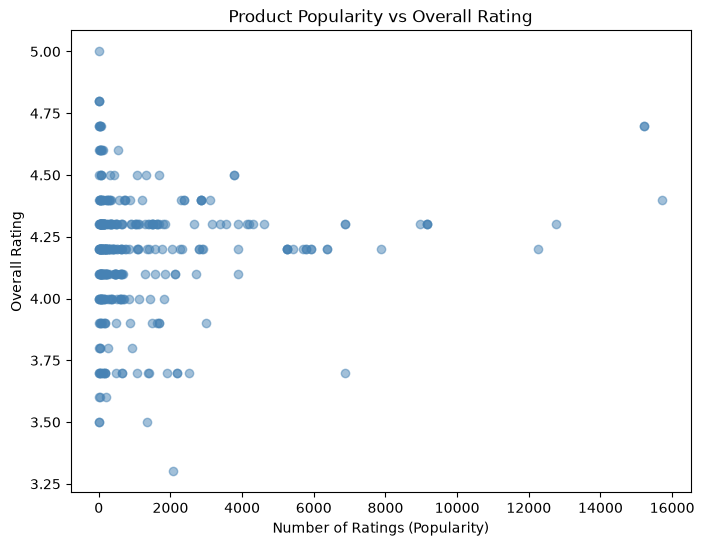

In [41]:
plt.figure(figsize=(8, 6))
plt.scatter(product_level["no_ratings"], product_level["overall_rating"], alpha=0.5, color="steelblue")
plt.title("Product Popularity vs Overall Rating")
plt.xlabel("Number of Ratings (Popularity)")
plt.ylabel("Overall Rating")
plt.show()

## Insight: Product popularity vs overall rating

What happened: Products with very few ratings show a wide range of overall ratings, from 3.3 to 5.0, 
while products with thousands of ratings consistently settle into a narrower band between 4.2 and 4.4.

Why it matters: This does not mean popular products are rated worse. It means ratings based on very 
few reviews are unstable and can be skewed by just one or two opinions, while ratings based on a large 
number of reviews are more statistically reliable. A product with a 5.0 rating from 2 reviews is not 
necessarily better than a product with a 4.3 rating from 15,000 reviews, it simply has not been tested 
by enough customers yet.

Recommendation: When comparing products by rating, the number of ratings should always be considered 
alongside the rating itself. A high rating from very few reviews should be treated with caution rather 
than as strong evidence of quality.

## Step 8: Correlation analysis

Here we check how the numeric variables in the dataset relate to each other using a correlation matrix. 
Correlation values range from -1 to 1. Values close to 1 mean two variables tend to increase together, 
values close to -1 mean one tends to increase while the other decreases, and values close to 0 mean 
little to no linear relationship.

In [42]:
# select numeric columns and calculate correlation between each pair
numeric_cols = df[["rating", "review_length", "overall_rating", "no_ratings", "no_reviews"]]
correlation_matrix = numeric_cols.corr()
correlation_matrix

,rating,review_length,overall_rating,no_ratings,no_reviews
rating,1.000000,-0.040966,0.163393,0.111453,0.124114
review_length,-0.040966,1.000000,0.135946,0.071601,0.092055
overall_rating,0.163393,0.135946,1.000000,0.233078,0.180723
no_ratings,0.111453,0.071601,0.233078,1.000000,0.905547
no_reviews,0.124114,0.092055,0.180723,0.905547,1.000000


## Correlation heatmap

A heatmap makes the correlation matrix easier to scan visually, using color intensity instead of 
reading each number individually.

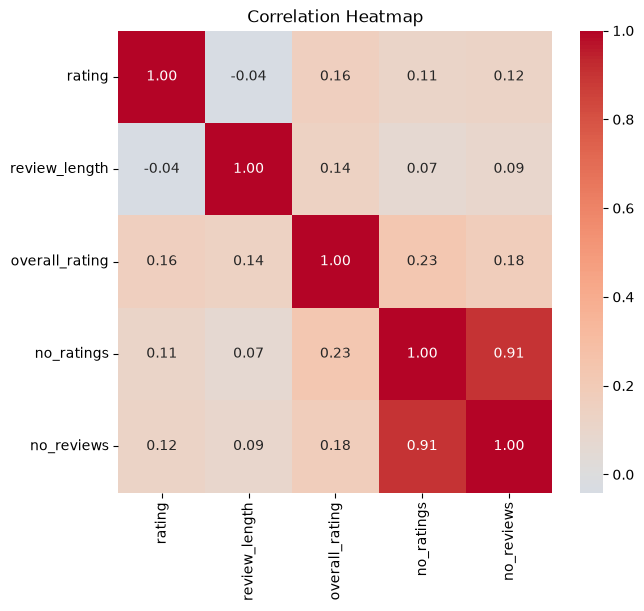

In [43]:
plt.figure(figsize=(7, 6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

## Insight: Correlation analysis

What happened: The strongest relationship in the dataset is between no_ratings and no_reviews, 
at 0.91, meaning products with more ratings almost always also have more written reviews. All other 
relationships in the dataset are weak, generally below 0.25, including between rating and review_length, 
which is close to zero.

Why it matters: The strong link between no_ratings and no_reviews is expected, since both measure the 
same underlying thing, how much attention a product has received, rather than two independent factors. 
It would be a mistake to treat this as two separate insights. The weak correlations elsewhere confirm 
that no single numeric variable in this dataset strongly predicts another, which suggests that the real 
signal for understanding customer sentiment likely lies in the text of the reviews themselves, not in 
these summary numbers. This is expected, and supports the core purpose of this project, since it is 
exactly why aspect based sentiment analysis on the review text is needed, rather than relying on 
star ratings and review counts alone.

Note on correlation versus causation: A high correlation between no_ratings and no_reviews does not 
mean one causes the other. Both are more likely explained by a third factor, the overall popularity 
and sales volume of the product, which drives both more ratings and more reviews at the same time.

## Note on time-series analysis

This dataset does not contain any date or timestamp column, so time-series analysis, such as 
identifying trends or seasonality over time, is not possible with the available data. This is 
noted as a limitation rather than skipped silently.

## Step 9: Multivariate analysis - brand, popularity, and rating

Here we look at three variables together: brand, how popular the product is, and rating. 
We first create a popularity tier for each product, grouping products into low, medium, 
and high popularity based on number of ratings. This lets us check whether a brand's rating 
looks different for its lesser known products versus its most popular ones.

In [44]:
# split products into 3 equal-sized popularity groups based on no_ratings
product_level["popularity_tier"] = pd.qcut(product_level["no_ratings"], q=3, labels=["Low", "Medium", "High"])

product_level["popularity_tier"].value_counts()

popularity_tier
Low       122
Medium    122
High      121
Name: count, dtype: int64

## Merge popularity tier back into the main dataset

The popularity tier was calculated at the product level. We now attach it back to every review row, 
so we can group reviews by brand and popularity tier together.

In [45]:
# bring popularity_tier into the main dataframe by matching on product_name
df = df.merge(product_level[["product_name", "popularity_tier"]], on="product_name", how="left")

df[["product_name", "popularity_tier"]].head(5)

,product_name,popularity_tier
0,Apple MacBook AIR Apple M2 - (8 GB/256 GB SSD/...,High
1,Apple MacBook AIR Apple M2 - (8 GB/256 GB SSD/...,High
2,Apple MacBook AIR Apple M2 - (8 GB/256 GB SSD/...,High
3,Apple MacBook AIR Apple M2 - (8 GB/256 GB SSD/...,High
4,Apple MacBook AIR Apple M2 - (8 GB/256 GB SSD/...,High


## Multivariate chart: average rating by brand and popularity tier

We now check whether a brand's rating changes depending on whether its products are low, medium, 
or high popularity. We limit this to the same set of brands used earlier, those with at least 
30 reviews, to keep the comparison reliable.

In [46]:
# reuse the reliable brand list from earlier (30+ reviews)
reliable_brands = brand_rating_filtered.index.tolist()

# filter to only those brands, then group by brand and popularity tier
grouped = df[df["brand"].isin(reliable_brands)].groupby(["brand", "popularity_tier"], observed=True)["rating"].mean().unstack()

grouped

popularity_tier,Low,Medium,High
brand,,,
ASUS,4.234568,4.189769,4.299703
AXL,NaN,3.878788,NaN
Acer,4.119048,3.935805,4.129278
Apple,NaN,4.843750,4.820000
CHUWI,NaN,4.131868,3.780000
Colorful,4.444444,NaN,NaN
DELL,4.186047,3.761589,4.237226
HP,3.977273,4.107011,4.264650
Infinix,4.238095,4.422460,4.275000


## Filtering to brands with complete data across all tiers

Several brands only have products in one or two popularity tiers, which would create a chart 
with many missing bars. We narrow the comparison to brands that have at least one product in 
every popularity tier, so the comparison is fair and complete.

In [47]:
# keep only brands with no missing values across all three tiers
grouped_complete = grouped.dropna()
grouped_complete

popularity_tier,Low,Medium,High
brand,,,
ASUS,4.234568,4.189769,4.299703
Acer,4.119048,3.935805,4.129278
DELL,4.186047,3.761589,4.237226
HP,3.977273,4.107011,4.264650
Infinix,4.238095,4.422460,4.275000
Lenovo,4.161074,4.103037,4.163374
MSI,4.375000,4.063694,4.297364


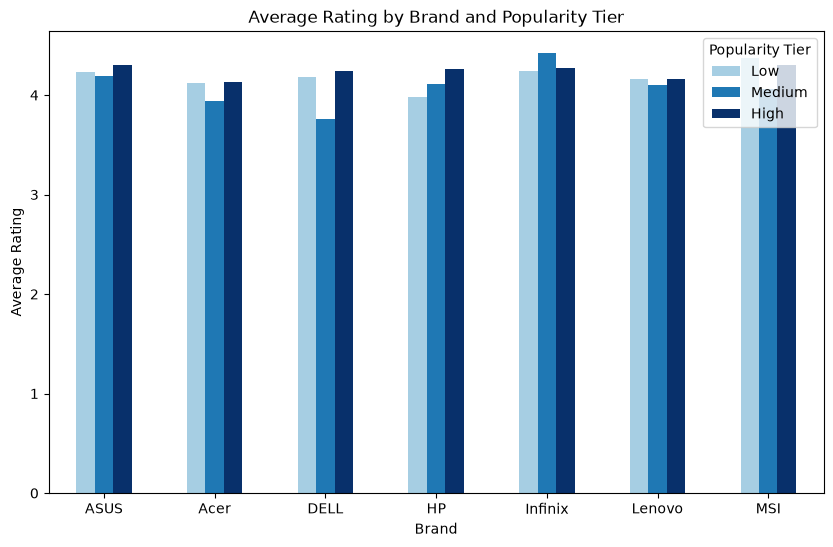

In [48]:
# reorder columns so bars appear Low, Medium, High from left to right
grouped_complete = grouped_complete[["Low", "Medium", "High"]]

grouped_complete.plot(kind="bar", figsize=(10, 6), color=["#a6cee3", "#1f78b4", "#08306b"])
plt.title("Average Rating by Brand and Popularity Tier")
plt.xlabel("Brand")
plt.ylabel("Average Rating")
plt.xticks(rotation=0)
plt.legend(title="Popularity Tier")
plt.show()

## Insight: Brand, popularity, and rating together

What happened: For most established brands, high popularity products have ratings equal to or higher 
than their low popularity products. Several brands, including DELL, Acer, and HP, show a dip in the 
medium popularity tier specifically, rather than a steady increase or decrease from low to high popularity.

Why it matters: This suggests that a brand's most popular products are generally not being rated worse 
as they scale up, which is a reassuring sign for brand reputation. The dip in the medium tier for some 
brands is unexpected and does not follow a simple pattern, it may be worth investigating further at the 
individual product level in a future stage of the project, rather than concluding a general rule from 
brand level averages alone.

Recommendation: Brands such as DELL and Acer could benefit from reviewing what differentiates their 
medium popularity products from their high popularity ones, since this dip is not explained by 
popularity alone and may point to specific product level issues.

## Business Insights and Recommendations

This section consolidates the key insights found throughout this notebook, along with the 
findings from the earlier data understanding notebook, into a single summary.

### Business Insights

1. The dataset contains 16,991 cleaned reviews across 365 products and 20 brands, following 
removal of duplicate rows and correction of numeric data types in the previous cleaning stage.

2. The overall rating distribution is heavily skewed toward positive reviews, 58 percent of 
reviews are 5 star, while only about 10 percent are 1 or 2 star combined.

3. About 3.7 percent of reviews are likely truncated by the scraper, ending mid-sentence with 
a literal READ MORE marker, a limitation to keep in mind for later text analysis.

4. Review length has almost no linear relationship with star rating overall, correlation of 
-0.04. The main pattern found is that 5 star reviews tend to be somewhat shorter on average 
than 1 to 4 star reviews.

5. Primebook, Apple, and realme have the highest average ratings among brands with sufficient 
review volume, while walker, Ultimus, and ZEBRONICS have the lowest.

6. The four most reviewed brands, HP, ASUS, Acer, and Lenovo, all sit in the middle of the 
rating range, performing decently but not exceptionally compared to smaller brands.

7. Products with very few ratings show highly variable overall ratings, from 3.3 to 5.0, while 
products with thousands of ratings settle into a stable range of 4.2 to 4.4. Rating reliability 
increases with review volume.

8. Among numeric variables, only no_ratings and no_reviews show a strong correlation with each 
other, 0.91, since both reflect overall product popularity. All other numeric relationships in 
the dataset are weak.

9. For most well established brands, high popularity products are rated equal to or higher than 
low popularity products, though several brands show an unexplained dip specifically in the medium 
popularity tier.

10. The dataset does not contain any date or timestamp column, so time based trend analysis was 
not possible with the available data.

### Recommendations

1. When building and evaluating the sentiment extraction model in later stages, account for the 
imbalance toward positive reviews, particularly by checking performance on negative reviews 
specifically, not just overall accuracy.

2. Treat product ratings based on very few reviews with caution when comparing products, since 
these are statistically less reliable than ratings based on large review volumes.

3. Investigate the specific complaints behind lower rated brands such as walker and Ultimus in 
the upcoming aspect extraction stage, to identify concrete, actionable product issues.

4. Since numeric variables show weak correlations overall, prioritize the review text itself as 
the primary source of insight going forward, this supports the core direction of the project.

5. Further investigate the medium popularity tier dip seen in brands like DELL and Acer at the 
individual product level, rather than treating it as a general brand wide pattern.

## Saving enriched dataset

The `brand` and `popularity_tier` columns created during this analysis are 
saved here so downstream notebooks can use them without recomputing this logic.